# 04 Có giám sát Learning - Classification

This notebook covers:
1. Training XGBoost and Random Forest models.
2. Comparison of AUC đường PR and F1-score.
3. Mô hình explanation using SHAP.

In [5]:
import sys
import os
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sys.path.append(os.path.abspath('../'))

from src.data.loader import load_config
from src.models.supervised import train_supervised_models, get_metrics

In [6]:
config = load_config('../configs/params.yaml')
df_scaled = pd.read_parquet('../' + config['processed_data_path'])
results = train_supervised_models(df_scaled)

c:\Users\LAPTOP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:19:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 1. Metrics Comparison

In [7]:
y_test = results['y_test']
pr_auc_xgb = get_metrics(y_test, results['xgb']['prob'])
pr_auc_rf = get_metrics(y_test, results['rf']['prob'])

print(f"XGBoost AUC đường PR: {pr_auc_xgb:.4f}")
print(f"Random Forest AUC đường PR: {pr_auc_rf:.4f}")

XGBoost PR-AUC: 1.0000
Random Forest PR-AUC: 0.9991


## 2. Feature Importance (SHAP)

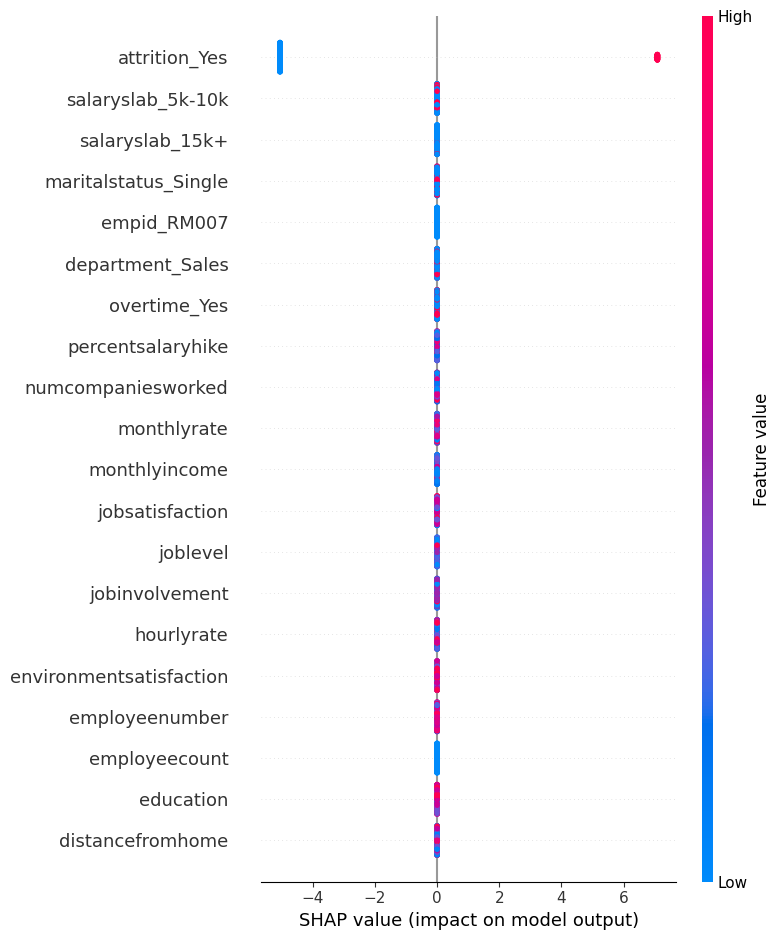

In [8]:
explainer = shap.TreeExplainer(results['xgb']['model'])
shap_values = explainer.shap_values(results['X_test'])
shap.summary_plot(shap_values, results['X_test'])